In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("1.cryptocurrency historical data.csv")

df.head()

,Currency,Date,Open,High,Low,Close,Volume,Market Cap
0,tezos,4-Dec-19,1.29,1.32,1.25,1.25,"46,048,752","824,588,509"
1,tezos,3-Dec-19,1.24,1.32,1.21,1.29,"41,462,224","853,213,342"
2,tezos,2-Dec-19,1.25,1.26,1.2,1.24,"27,574,097","817,872,179"
3,tezos,1-Dec-19,1.33,1.34,1.25,1.25,"24,127,567","828,296,390"
4,tezos,30-Nov-19,1.31,1.37,1.31,1.33,"28,706,667","879,181,680"


In [3]:
df.shape

(28944, 8)

In [4]:
df.columns

Index(['Currency', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume',
       'Market Cap'],
      dtype='object')

In [5]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Convert numerical columns from text to numbers
numeric_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Market Cap"
]

for col in numeric_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace("-", np.nan)
        .astype(float)
    )

print("Data cleaning completed!")

/tmp/ipykernel_714/2578390872.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


Data cleaning completed!


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28944 entries, 0 to 28943
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Currency    28944 non-null  object        
 1   Date        28944 non-null  datetime64[ns]
 2   Open        28944 non-null  float64       
 3   High        28944 non-null  float64       
 4   Low         28944 non-null  float64       
 5   Close       28944 non-null  float64       
 6   Volume      28944 non-null  float64       
 7   Market Cap  28944 non-null  float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 1.8+ MB


In [7]:
df.isnull().sum()

,0
Currency,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
Market Cap,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
btc = df[df["Currency"] == "bitcoin"].copy()

btc = btc.sort_values("Date")

btc.head()

,Currency,Date,Open,High,Low,Close,Volume,Market Cap
9647,bitcoin,2013-04-28,135.30,135.98,132.10,134.21,0.0,1.488567e+09
9646,bitcoin,2013-04-29,134.44,147.49,134.00,144.54,0.0,1.603769e+09
9645,bitcoin,2013-04-30,144.00,146.93,134.05,139.00,0.0,1.542813e+09
9644,bitcoin,2013-05-01,139.00,139.89,107.72,116.99,0.0,1.298955e+09
9643,bitcoin,2013-05-02,116.38,125.60,92.28,105.21,0.0,1.168517e+09


In [10]:
btc_prices = btc["Close"].to_numpy()

print(btc_prices[:10])

[134.21 144.54 139.   116.99 105.21  97.75 112.5  115.91 112.3  111.5 ]


In [11]:
daily_change = (
    np.diff(btc_prices) / btc_prices[:-1]
) * 100

print(daily_change[:10])

[  7.69689293  -3.83284904 -15.83453237 -10.06923669  -7.09058074
  15.08951407   3.03111111  -3.11448538  -0.71237756   1.85650224]


In [12]:
print("Average Daily Change:", np.mean(daily_change))
print("Maximum Daily Change:", np.max(daily_change))
print("Minimum Daily Change:", np.min(daily_change))

Average Daily Change: 0.25751968803150205
Maximum Daily Change: 42.96803560179633
Minimum Daily Change: -23.371254324752236


In [13]:
# Find the latest date in the dataset
latest_date = df["Date"].max()

# Find the date 6 months before the latest date
six_months_ago = latest_date - pd.DateOffset(months=6)

print("Latest Date:", latest_date)
print("Six Months Ago:", six_months_ago)

Latest Date: 2019-12-04 00:00:00
Six Months Ago: 2019-06-04 00:00:00


In [14]:
ethereum_6_months = df[
    (df["Currency"] == "ethereum") &
    (df["Date"] >= six_months_ago)
].copy()

ethereum_6_months.head()

,Currency,Date,Open,High,Low,Close,Volume,Market Cap
21708,ethereum,2019-12-04,147.92,150.68,145.00,146.75,7.865937e+09,1.596616e+10
21709,ethereum,2019-12-03,149.06,150.31,146.00,147.96,6.204380e+09,1.609593e+10
21710,ethereum,2019-12-02,151.18,152.12,147.61,149.06,6.670561e+09,1.621413e+10
21711,ethereum,2019-12-01,152.49,152.49,147.07,151.19,7.102780e+09,1.644365e+10
21712,ethereum,2019-11-30,155.29,156.69,151.23,152.54,6.565951e+09,1.658913e+10


In [15]:
print("Number of Ethereum records:", len(ethereum_6_months))

Number of Ethereum records: 184


In [16]:
ethereum_6_months[[
    "Date",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]].head(10)

,Date,Open,High,Low,Close,Volume
21708,2019-12-04,147.92,150.68,145.00,146.75,7.865937e+09
21709,2019-12-03,149.06,150.31,146.00,147.96,6.204380e+09
21710,2019-12-02,151.18,152.12,147.61,149.06,6.670561e+09
21711,2019-12-01,152.49,152.49,147.07,151.19,7.102780e+09
21712,2019-11-30,155.29,156.69,151.23,152.54,6.565951e+09
21713,2019-11-29,151.77,156.85,151.46,155.30,7.503898e+09
21714,2019-11-28,153.07,156.61,151.09,151.72,7.346532e+09
21715,2019-11-27,148.40,154.89,143.53,153.01,8.778095e+09
21716,2019-11-26,146.40,150.00,145.22,148.97,7.648516e+09
21717,2019-11-25,142.70,150.21,133.80,146.48,1.096275e+10


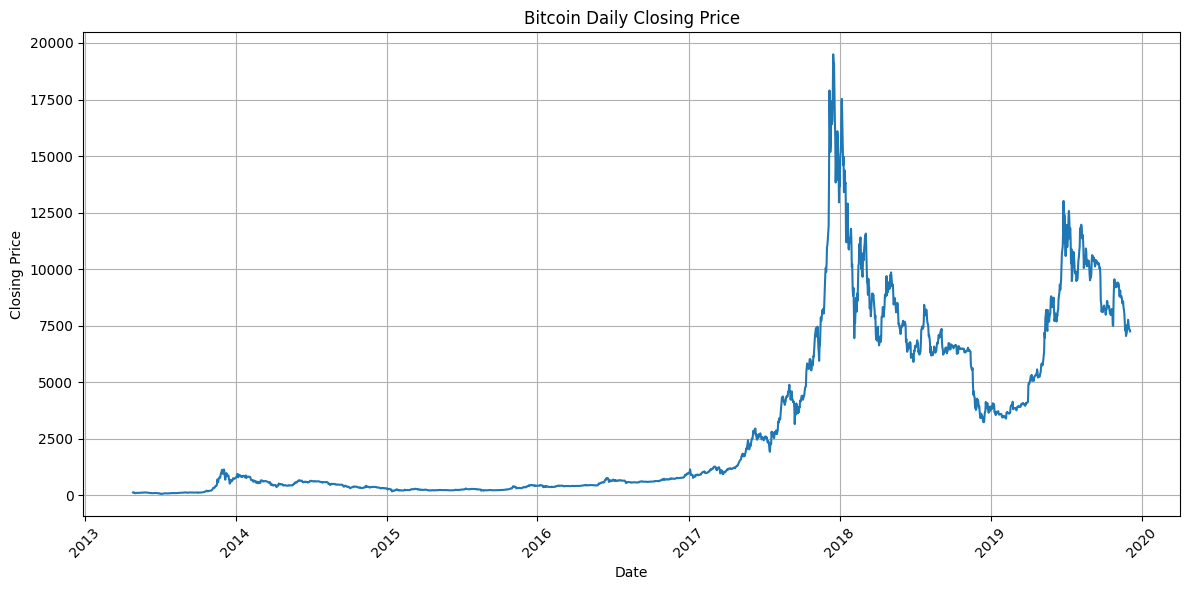

In [17]:
plt.figure(figsize=(12, 6))

plt.plot(
    btc["Date"],
    btc["Close"],
    linewidth=1.5
)

plt.title("Bitcoin Daily Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [18]:
highest_price = btc["Close"].max()
lowest_price = btc["Close"].min()

print("Highest Bitcoin Closing Price:", highest_price)
print("Lowest Bitcoin Closing Price:", lowest_price)

Highest Bitcoin Closing Price: 19497.4
Lowest Bitcoin Closing Price: 68.43


In [19]:
highest_date = btc.loc[
    btc["Close"].idxmax(),
    "Date"
]

lowest_date = btc.loc[
    btc["Close"].idxmin(),
    "Date"
]

print("Highest Price Date:", highest_date)
print("Lowest Price Date:", lowest_date)

Highest Price Date: 2017-12-16 00:00:00
Lowest Price Date: 2013-07-05 00:00:00


In [20]:
df["Volume"].describe()

,Volume
count,2.894400e+04
mean,8.133058e+08
std,3.059516e+09
min,0.000000e+00
25%,2.418700e+05
50%,5.212684e+06
75%,1.554764e+08
max,5.350913e+10


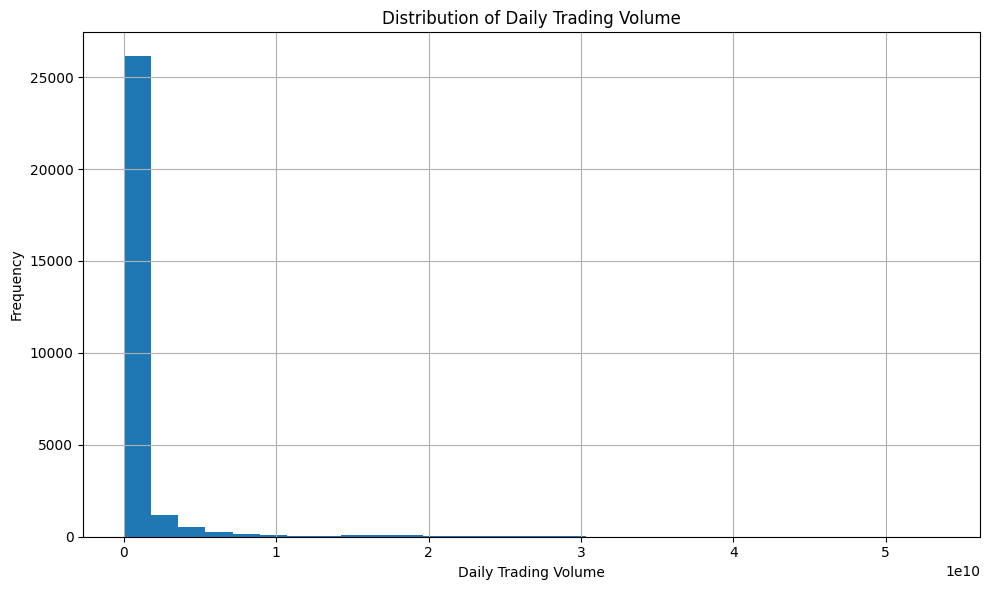

In [21]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Volume"].dropna(),
    bins=30
)

plt.title("Distribution of Daily Trading Volume")
plt.xlabel("Daily Trading Volume")
plt.ylabel("Frequency")

plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
btc_mean = btc["Close"].mean()
btc_median = btc["Close"].median()

print("Bitcoin Mean Closing Price:", btc_mean)
print("Bitcoin Median Closing Price:", btc_median)

Bitcoin Mean Closing Price: 3023.4987769485906
Bitcoin Median Closing Price: 701.9449999999999


In [26]:
eth = df[df["Currency"] == "ethereum"].copy()

eth = eth.sort_values("Date")

print("Ethereum data loaded:", len(eth), "rows")

Ethereum data loaded: 2412 rows


In [27]:
print("Bitcoin")
print("Mean   :", btc["Close"].mean())
print("Median :", btc["Close"].median())

print()

print("Ethereum")
print("Mean   :", eth["Close"].mean())
print("Median :", eth["Close"].median())

Bitcoin
Mean   : 3023.4987769485906
Median : 701.9449999999999

Ethereum
Mean   : 263.43461004519077
Median : 211.345


In [28]:
btc["Daily_Return"] = btc["Close"].pct_change() * 100

btc[["Date", "Close", "Daily_Return"]].head()

,Date,Close,Daily_Return
9647,2013-04-28,134.21,NaN
9646,2013-04-29,144.54,7.696893
9645,2013-04-30,139.00,-3.832849
9644,2013-05-01,116.99,-15.834532
9643,2013-05-02,105.21,-10.069237


In [29]:
btc_volatility = btc["Daily_Return"].std()

print("Bitcoin Daily Return Standard Deviation:", btc_volatility)

Bitcoin Daily Return Standard Deviation: 4.302677728162678


In [30]:
print("Bitcoin Average Daily Return:",
      btc["Daily_Return"].mean())

print("Bitcoin Volatility (Standard Deviation):",
      btc["Daily_Return"].std())

Bitcoin Average Daily Return: 0.25751968803150205
Bitcoin Volatility (Standard Deviation): 4.302677728162678


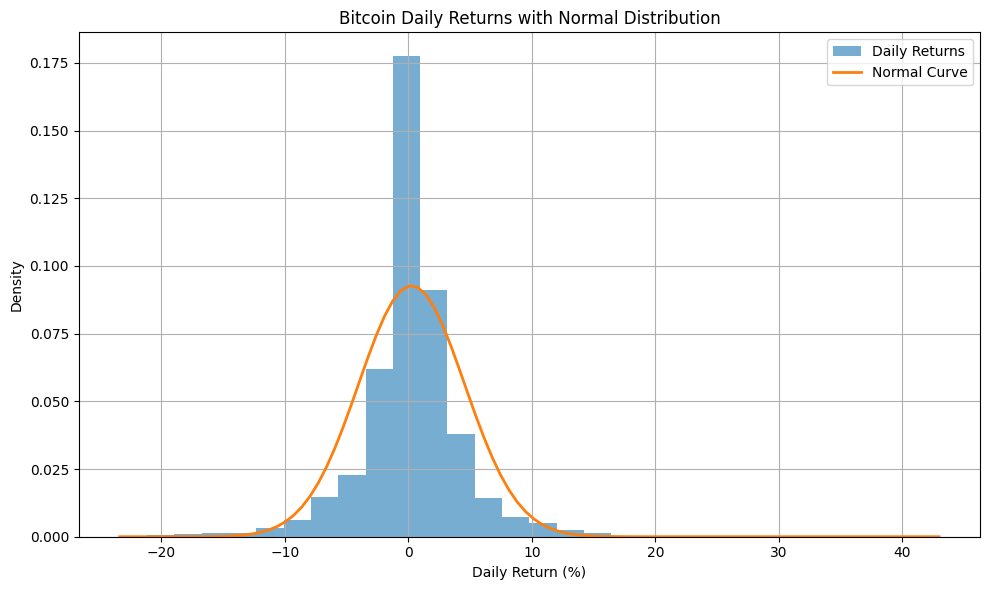

In [31]:
returns = btc["Daily_Return"].dropna()

mean = returns.mean()
std = returns.std()

plt.figure(figsize=(10, 6))

plt.hist(
    returns,
    bins=30,
    density=True,
    alpha=0.6,
    label="Daily Returns"
)

x = np.linspace(returns.min(), returns.max(), 100)

normal_curve = stats.norm.pdf(
    x,
    mean,
    std
)

plt.plot(
    x,
    normal_curve,
    linewidth=2,
    label="Normal Curve"
)

plt.title("Bitcoin Daily Returns with Normal Distribution")
plt.xlabel("Daily Return (%)")
plt.ylabel("Density")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [32]:
btc_data = btc[["Date", "Close"]].rename(
    columns={"Close": "Bitcoin"}
)

eth_data = eth[["Date", "Close"]].rename(
    columns={"Close": "Ethereum"}
)

merged = pd.merge(
    btc_data,
    eth_data,
    on="Date"
)

print(merged.head())
print("Merged rows:", len(merged))

        Date  Bitcoin  Ethereum
0 2013-04-28   134.21    134.21
1 2013-04-29   144.54    144.54
2 2013-04-30   139.00    139.00
3 2013-05-01   116.99    116.99
4 2013-05-02   105.21    105.21
Merged rows: 2412


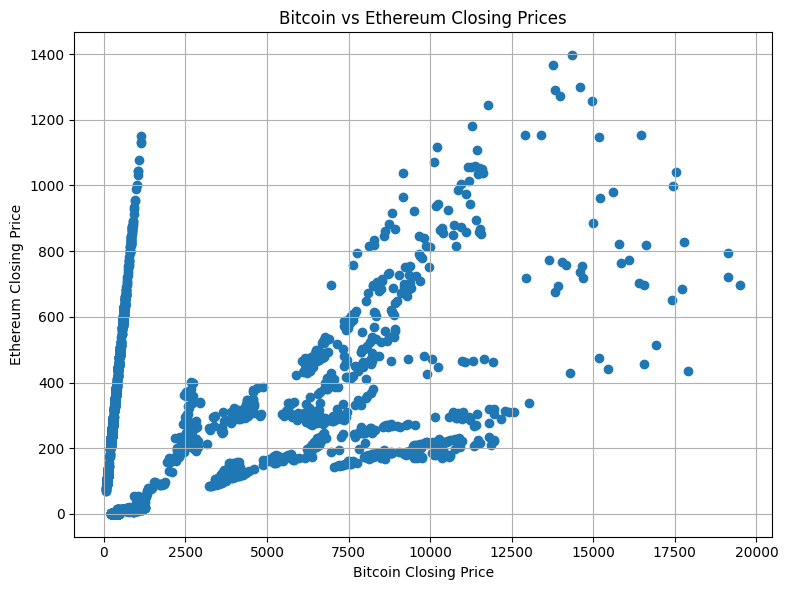

In [33]:
plt.figure(figsize=(8, 6))

plt.scatter(
    merged["Bitcoin"],
    merged["Ethereum"]
)

plt.title("Bitcoin vs Ethereum Closing Prices")
plt.xlabel("Bitcoin Closing Price")
plt.ylabel("Ethereum Closing Price")

plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
correlation = merged["Bitcoin"].corr(
    merged["Ethereum"]
)

print("Pearson Correlation:", correlation)

Pearson Correlation: 0.3883478531322355


In [35]:
X = merged[["Bitcoin"]]
y = merged["Ethereum"]

model = LinearRegression()

model.fit(X, y)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

merged["Predicted_Ethereum"] = model.predict(X)

Slope: 0.025902138958804815
Intercept: 185.11952458289198


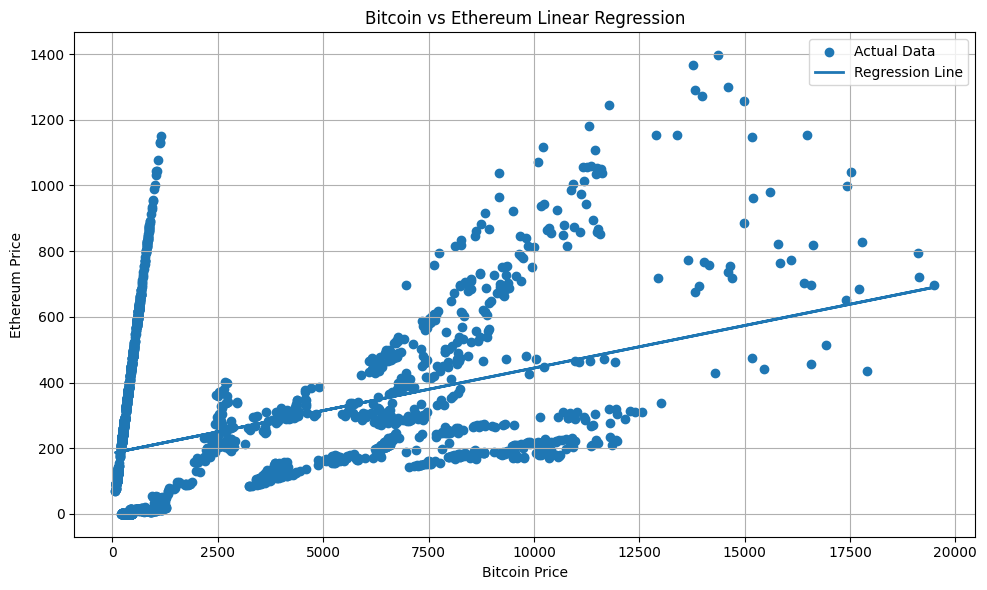

In [36]:
plt.figure(figsize=(10, 6))

plt.scatter(
    merged["Bitcoin"],
    merged["Ethereum"],
    label="Actual Data"
)

plt.plot(
    merged["Bitcoin"],
    merged["Predicted_Ethereum"],
    linewidth=2,
    label="Regression Line"
)

plt.title("Bitcoin vs Ethereum Linear Regression")
plt.xlabel("Bitcoin Price")
plt.ylabel("Ethereum Price")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [37]:
print("========== CRYPTOCURRENCY DATA ANALYSIS RESULTS ==========")

print("\n1. Bitcoin Mean Closing Price:")
print(btc["Close"].mean())

print("\n2. Bitcoin Median Closing Price:")
print(btc["Close"].median())

print("\n3. Ethereum Mean Closing Price:")
print(eth["Close"].mean())

print("\n4. Ethereum Median Closing Price:")
print(eth["Close"].median())

print("\n5. Bitcoin Daily Return Mean:")
print(btc["Daily_Return"].mean())

print("\n6. Bitcoin Volatility (Standard Deviation):")
print(btc["Daily_Return"].std())

print("\n7. Pearson Correlation (BTC vs ETH):")
print(merged["Bitcoin"].corr(merged["Ethereum"]))

print("\n8. Regression Slope:")
print(model.coef_[0])

print("\n9. Regression Intercept:")
print(model.intercept_)

========== CRYPTOCURRENCY DATA ANALYSIS RESULTS ==========

1. Bitcoin Mean Closing Price:
3023.4987769485906

2. Bitcoin Median Closing Price:
701.9449999999999

3. Ethereum Mean Closing Price:
263.43461004519077

4. Ethereum Median Closing Price:
211.345

5. Bitcoin Daily Return Mean:
0.25751968803150205

6. Bitcoin Volatility (Standard Deviation):
4.302677728162678

7. Pearson Correlation (BTC vs ETH):
0.3883478531322355

8. Regression Slope:
0.025902138958804815

9. Regression Intercept:
185.11952458289198
